# 03 — Modelo, Métricas y Preprocesamiento
## Smart Kitchen Intelligence (SKI) — Entrega 3 | Semana 7

**Curso:** Data Visualization — UPC  
**Dataset:** `data/interim/inventory_v1.csv` (25 819 eventos, 17 variables)  
**Fecha de ejecución:** 2026-05-15  

---

### Pregunta analítica

> **¿Es posible predecir si un evento de salida (OUT) resultará en desperdicio alimentario (Waste / Forced_Waste) versus consumo normal, a partir del perfil nutricional del producto, su ubicación y la cantidad involucrada?**

Este es un problema de **clasificación binaria** con impacto directo en la gestión del inventario doméstico.

### Estructura del notebook

1. Configuración e importaciones  
2. Carga y validación de datos  
3. Análisis exploratorio rápido (pre-modelado)  
4. Preprocesamiento — tratamiento de nulos, encoding, escalado  
5. División train / test  
6. Modelo 1 — Regresión Logística (baseline)  
7. Modelo 2 — Random Forest Classifier (principal)  
8. Comparación de métricas  
9. Conclusión técnica y selección del modelo final  

---
## 1. Configuración e importaciones

In [1]:
# ─── Librerías estándar ───────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ─── outputs/ se crea AQUÍ — antes de cualquier plt.savefig ──────────────────
os.makedirs('../outputs', exist_ok=True)

# ─── Datos ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ─── Visualización ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Preprocesamiento ─────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# ─── Modelos ──────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ─── Métricas ─────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ─── Reproducibilidad ─────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ─── Estilo ───────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('✓ Librerías importadas correctamente.')
print('✓ Directorio ../outputs/ listo.')

✓ Librerías importadas correctamente.
✓ Directorio ../outputs/ listo.


---
## 2. Carga y validación de datos

In [2]:
# ─── Carga desde el dataset analítico generado en la Entrega 2 ────────────────
DATA_PATH = '../data/interim/inventory_v1.csv'

df = pd.read_csv(
    DATA_PATH,
    parse_dates=['timestamp', 'expiry_date'],
    dtype={
        'event_id':       'string',
        'household_id':   'Int64',
        'product_id':     'Int64',
        'action_type':    'category',
        'classification': 'category',
        'location':       'category',
        'category_name':  'category',
        'nutriscore':     'category',
    }
)

print(f'Registros cargados : {len(df):,}')
print(f'Variables          : {df.shape[1]}')
print(f'Rango temporal     : {df["timestamp"].min().date()} → {df["timestamp"].max().date()}')
print()
print(df.dtypes)

Registros cargados : 25,819
Variables          : 17
Rango temporal     : 2026-02-01 → 2026-05-01

event_id            string[python]
household_id                 Int64
stock_id                    object
product_id                   Int64
product_name                object
action_type               category
quantity                     int64
timestamp           datetime64[ns]
expiry_date         datetime64[ns]
classification            category
location                  category
category_name             category
dias_para_vencer             int64
nutriscore                category
calories_100g              float64
proteins_100g              float64
carbs_100g                 float64
dtype: object


In [3]:
df.head(5)

,event_id,household_id,stock_id,product_id,product_name,action_type,quantity,timestamp,expiry_date,classification,location,category_name,dias_para_vencer,nutriscore,calories_100g,proteins_100g,carbs_100g
0,abe14959-9,3,2b5836f4,27966,Organic Raspberries,IN,2,2026-03-15 13:33:36,2026-03-22,Purchase,Refrigerador,Frutas y Verduras,7,B,50.0,1.430,12.10
1,39ccee30-a,4,f9e17f0f,17794,Carrots,OUT,1,2026-04-23 08:32:36,2026-04-25,Consumption,Refrigerador,Frutas y Verduras,2,A,38.0,1.280,8.97
2,03660175-6,3,188b9c63,21616,Organic Baby Arugula,IN,2,2026-04-01 13:06:36,2026-04-08,Purchase,Refrigerador,Frutas y Verduras,7,A,25.0,2.820,3.52
3,d704db02-9,1,54384ea8,24964,Organic Garlic,IN,3,2026-04-30 08:09:36,2026-05-07,Purchase,Refrigerador,Frutas y Verduras,7,C,167.0,0.000,33.30
4,30019698-2,6,e4b37ec8,10749,Organic Red Bell Pepper,OUT,1,2026-03-14 23:59:59,2026-03-11,Forced_Waste,Refrigerador,Frutas y Verduras,-3,NaN,NaN,0.896,6.65


In [4]:
df.describe(percentiles=[0.25, 0.50, 0.75]).T

,count,mean,min,25%,50%,75%,max,std
household_id,25819.0,4.499516,0.0,2.0,4.0,7.0,9.0,2.819174
product_id,25819.0,28910.604013,4605.0,19660.0,27966.0,41950.0,49683.0,13466.388241
quantity,25819.0,1.731516,1.0,1.0,2.0,2.0,3.0,0.797608
timestamp,25819,2026-03-19 08:49:07.268949248,2026-02-01 10:01:36,2026-02-26 08:11:36,2026-03-18 14:01:36,2026-04-10 09:34:36,2026-05-01 23:59:59,NaN
expiry_date,25819,2026-03-24 06:23:19.620434176,2026-02-08 00:00:00,2026-03-03 00:00:00,2026-03-23 00:00:00,2026-04-15 00:00:00,2026-05-31 00:00:00,NaN
dias_para_vencer,25819.0,5.502847,-3.0,2.0,7.0,7.0,30.0,6.201357
calories_100g,22243.0,106.751562,0.0,30.0,50.0,131.0,427.0,126.598266
proteins_100g,25819.0,2.261476,0.0,0.5,1.28,2.82,12.5,2.977079
carbs_100g,25819.0,16.024914,0.0,5.01,7.43,14.3,90.0,22.169704


---
## 3. Análisis exploratorio rápido (pre-modelado)

In [5]:
# ─── Distribuciones del target y variables clave ──────────────────────────────
print('classification (todos los eventos):')
print(df['classification'].value_counts())
print()
print('action_type:')
print(df['action_type'].value_counts())
print()
nulos = df.isnull().sum()
print('Nulos por columna (solo columnas con nulos):')
print(nulos[nulos > 0])

classification (todos los eventos):
classification
Purchase        11581
Consumption      9185
Forced_Waste     3531
Waste            1522
Name: count, dtype: int64

action_type:
action_type
OUT    14238
IN     11581
Name: count, dtype: int64

Nulos por columna (solo columnas con nulos):
nutriscore       3576
calories_100g    3576
dtype: int64


In [6]:
# ─── Nota sobre dias_para_vencer — leakage confirmado ─────────────────────────
# Análisis previo detectó que dias_para_vencer es el criterio exacto con el que
# el simulador asignó las etiquetas: todos los Forced_Waste tienen
# dias_para_vencer < 0, y todos los Waste también. Incluirla trivializa el
# problema (F1=1.0, AUC=1.0) sin aprendizaje real.
# → Se excluye de los features. Se mantiene en el dataset para análisis de Tableau.
out_sub = df[df['action_type'] == 'OUT'].copy()
print('Verificación de leakage — mediana dias_para_vencer por classification:')
print(out_sub.groupby('classification', observed=True)['dias_para_vencer'].median())
print()
print('→ Forced_Waste y Waste son 100% negativos (producto vencido al momento del OUT).')
print('  Incluir esta variable hace la predicción trivial. Se excluye del modelado.')

Verificación de leakage — mediana dias_para_vencer por classification:
classification
Consumption     5.0
Forced_Waste   -3.0
Waste          -2.0
Name: dias_para_vencer, dtype: float64

→ Forced_Waste y Waste son 100% negativos (producto vencido al momento del OUT).
  Incluir esta variable hace la predicción trivial. Se excluye del modelado.


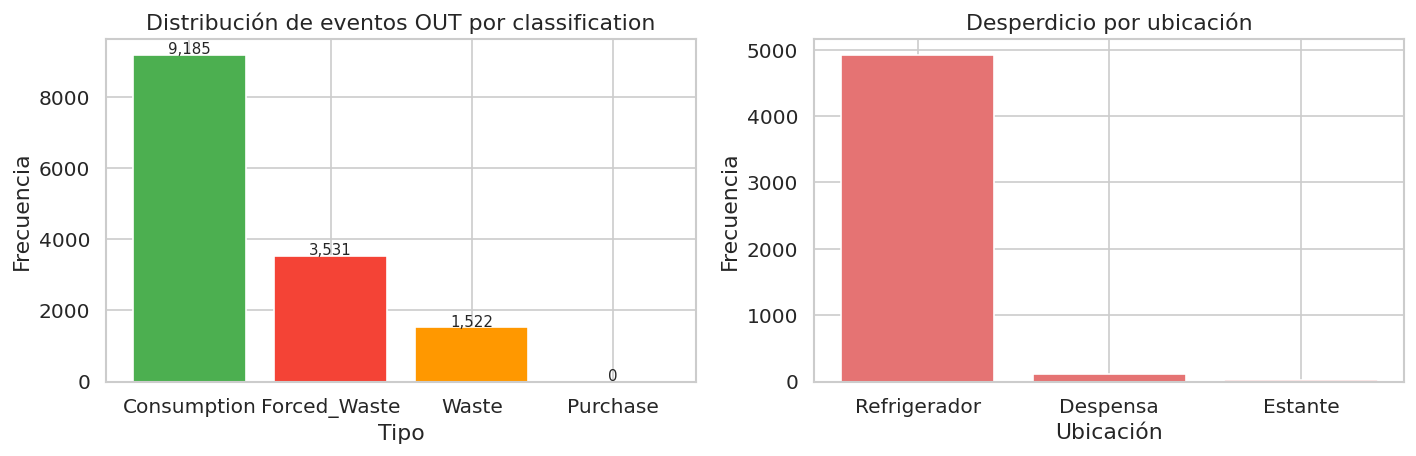

Eventos OUT: 14,238  |  Consumo: 9,185  |  Desperdicio: 5,053


In [7]:
# ─── Visualización: distribución de eventos OUT ───────────────────────────────
out_events = df[df['action_type'] == 'OUT'].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = out_events['classification'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50', '#F44336', '#FF9800'])
axes[0].set_title('Distribución de eventos OUT por classification')
axes[0].set_xlabel('Tipo'); axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 40, f'{v:,}', ha='center', fontsize=9)

waste_by_loc = (
    out_events[out_events['classification'].isin(['Waste','Forced_Waste'])]
    .groupby('location', observed=True).size().sort_values(ascending=False)
)
axes[1].bar(waste_by_loc.index, waste_by_loc.values, color='#E57373')
axes[1].set_title('Desperdicio por ubicación')
axes[1].set_xlabel('Ubicación'); axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('../outputs/eda_distribucion_target.png', bbox_inches='tight')
plt.show()

print(f'Eventos OUT: {len(out_events):,}  |  '
      f'Consumo: {(out_events["classification"]=="Consumption").sum():,}  |  '
      f'Desperdicio: {out_events["classification"].isin(["Waste","Forced_Waste"]).sum():,}')

---
## 4. Preprocesamiento

### 4.1 Subconjunto analítico y target binario

- **Subconjunto**: solo eventos `OUT` — los `IN` son siempre compras, no clasificables como desperdicio.
- **Target**: `is_waste = 1` si `classification ∈ {Waste, Forced_Waste}`, `0` si `Consumption`.
- **`dias_para_vencer` excluida de features** — es leakage: el simulador la usó para asignar las etiquetas determinísticamente.

In [8]:
# ─── 4.1 Subconjunto y target binario ─────────────────────────────────────────
model_df = df[df['action_type'] == 'OUT'].copy()
model_df['is_waste'] = model_df['classification'].isin(['Waste','Forced_Waste']).astype(int)

balance = model_df['is_waste'].value_counts(normalize=True).mul(100).round(1)
print(f'Subconjunto: {len(model_df):,} eventos OUT')
print()
print('Balance de clases:')
print(balance.rename({0: 'Consumo (0)', 1: 'Desperdicio (1)'}))

if balance.max() > 70:
    print(f'\n⚠ Desbalance detectado ({balance.max():.1f}% clase mayoritaria).')
    print('  → Métrica primaria: F1-Score y ROC-AUC.')
    print('  → Se aplica class_weight="balanced" en ambos modelos.')

Subconjunto: 14,238 eventos OUT

Balance de clases:
is_waste
Consumo (0)        64.5
Desperdicio (1)    35.5
Name: proportion, dtype: float64


### 4.2 Selección de features

| Feature | Tipo | Justificación de inclusión |
|---|---|---|
| `calories_100g` | Numérico | Densidad energética — proxy de tipo de alimento |
| `proteins_100g` | Numérico | Perfil proteico del producto |
| `carbs_100g` | Numérico | Contenido de carbohidratos |
| `quantity` | Numérico | Cantidad de unidades del evento |
| `location` | Categórico nominal | Ubicación física (Refrigerador / Despensa / Estante) |
| `category_name` | Categórico nominal | Categoría del producto (6 clases) |
| `nutriscore` | Ordinal | Calidad nutricional: A (mejor) → E (peor) |

**Excluidas deliberadamente:** `dias_para_vencer` (leakage), `household_id` (overfitting a IDs sintéticos), `action_type` (constante en el subconjunto).

In [9]:
# ─── 4.2 Definición de features ───────────────────────────────────────────────
NUMERIC_FEATURES     = ['calories_100g', 'proteins_100g', 'carbs_100g', 'quantity']
CATEGORICAL_FEATURES = ['location', 'category_name']
ORDINAL_FEATURES     = ['nutriscore']
TARGET               = 'is_waste'

feature_cols = NUMERIC_FEATURES + CATEGORICAL_FEATURES + ORDINAL_FEATURES
model_data   = model_df[feature_cols + [TARGET]].copy()

print(f'Features: {len(feature_cols)} variables')
print(f'  Numéricas   ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'  Categóricas ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print(f'  Ordinales   ({len(ORDINAL_FEATURES)}): {ORDINAL_FEATURES}')
print(f'\nShape del dataset de modelado: {model_data.shape}')
print('\nNulos por feature:')
print(model_data[feature_cols].isnull().sum())

Features: 7 variables
  Numéricas   (4): ['calories_100g', 'proteins_100g', 'carbs_100g', 'quantity']
  Categóricas (2): ['location', 'category_name']
  Ordinales   (1): ['nutriscore']

Shape del dataset de modelado: (14238, 8)

Nulos por feature:
calories_100g    1974
proteins_100g       0
carbs_100g          0
quantity            0
location            0
category_name       0
nutriscore       1974
dtype: int64


### 4.3 Pipeline de preprocesamiento

Se usa `sklearn.Pipeline` + `ColumnTransformer` — las transformaciones se ajustan **sólo** con datos de entrenamiento para evitar data leakage.

- **Numéricas**: imputación con mediana (robusta a outliers) → StandardScaler
- **Categóricas**: imputación constante `'Desconocido'` → OneHotEncoder
- **Nutriscore**: imputación con moda → OrdinalEncoder `[A→0, B→1, C→2, D→3, E→4]`

In [10]:
# ─── 4.3 ColumnTransformer ────────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconocido')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# unknown_value=-1: fuera del rango 0–4, no colisiona con ninguna categoría
ordinal_transformer = Pipeline([
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  OrdinalEncoder(
        categories=[['A','B','C','D','E']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,     NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
    ('ord', ordinal_transformer,     ORDINAL_FEATURES),
], remainder='drop')

print('✓ ColumnTransformer construido.')
print('  Numérico   → Impute(mediana) + StandardScaler')
print('  Categórico → Impute(constante) + OneHotEncoder')
print('  Ordinal    → Impute(moda) + OrdinalEncoder [A→0, E→4]')

✓ ColumnTransformer construido.
  Numérico   → Impute(mediana) + StandardScaler
  Categórico → Impute(constante) + OneHotEncoder
  Ordinal    → Impute(moda) + OrdinalEncoder [A→0, E→4]


---
## 5. División train / test

Partición **80 / 20** con estratificación sobre el target para preservar el balance de clases.

In [11]:
# ─── 5. Split estratificado ───────────────────────────────────────────────────
X = model_data[feature_cols]
y = model_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Total       : {len(X):,}')
print(f'Entrena (80%): {len(X_train):,} | Prueba (20%): {len(X_test):,}')
print()
print('Balance en train:'); print(y_train.value_counts(normalize=True).mul(100).round(1))
print('Balance en test:');  print(y_test.value_counts(normalize=True).mul(100).round(1))

Total       : 14,238
Entrena (80%): 11,390 | Prueba (20%): 2,848

Balance en train:
is_waste
0    64.5
1    35.5
Name: proportion, dtype: float64
Balance en test:
is_waste
0    64.5
1    35.5
Name: proportion, dtype: float64


---
## 6. Modelo 1 — Regresión Logística (Baseline)

Modelo simple, interpretable y rápido. Establece el piso de referencia.
Asume linealidad entre features y log-odds del target.

In [12]:
# ─── 6.1 Pipeline LR ──────────────────────────────────────────────────────────
pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(
        class_weight='balanced', max_iter=500,
        random_state=RANDOM_STATE, solver='lbfgs'
    ))
])
pipeline_lr.fit(X_train, y_train)
print('✓ Regresión Logística entrenada.')

✓ Regresión Logística entrenada.


In [13]:
# ─── 6.2 Métricas ─────────────────────────────────────────────────────────────
y_pred_lr  = pipeline_lr.predict(X_test)
y_proba_lr = pipeline_lr.predict_proba(X_test)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, zero_division=0)
auc_lr  = roc_auc_score(y_test, y_proba_lr)

print('═══════════════════════════════════════')
print('    MÉTRICAS — Regresión Logística     ')
print('═══════════════════════════════════════')
print(f'  Accuracy  : {acc_lr:.4f}')
print(f'  Precision : {prec_lr:.4f}')
print(f'  Recall    : {rec_lr:.4f}')
print(f'  F1-Score  : {f1_lr:.4f}  ← métrica primaria')
print(f'  ROC-AUC   : {auc_lr:.4f}')
print('═══════════════════════════════════════')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Consumo','Desperdicio']))

═══════════════════════════════════════
    MÉTRICAS — Regresión Logística     
═══════════════════════════════════════
  Accuracy  : 0.5779
  Precision : 0.4309
  Recall    : 0.5895
  F1-Score  : 0.4979  ← métrica primaria
  ROC-AUC   : 0.6231
═══════════════════════════════════════

              precision    recall  f1-score   support

     Consumo       0.72      0.57      0.64      1837
 Desperdicio       0.43      0.59      0.50      1011

    accuracy                           0.58      2848
   macro avg       0.57      0.58      0.57      2848
weighted avg       0.62      0.58      0.59      2848



In [14]:
# ─── 6.3 Validación cruzada 5-fold ────────────────────────────────────────────
cv_scores_lr = cross_val_score(pipeline_lr, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'F1 CV 5-fold (LR): {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')

F1 CV 5-fold (LR): 0.4904 ± 0.0165


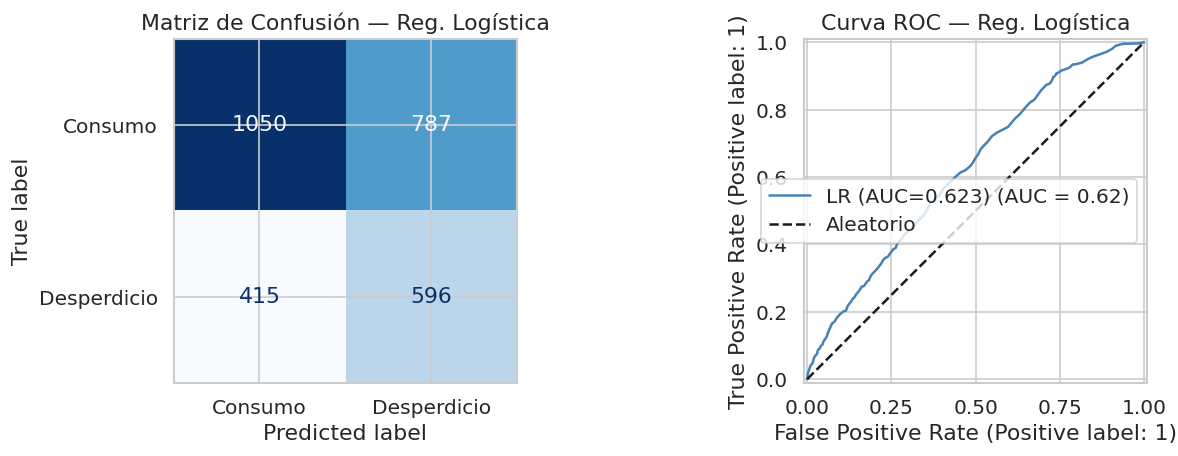

In [15]:
# ─── 6.4 Matriz de confusión y curva ROC ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=['Consumo','Desperdicio'],
    colorbar=False, ax=axes[0], cmap='Blues'
)
axes[0].set_title('Matriz de Confusión — Reg. Logística')
RocCurveDisplay.from_predictions(
    y_test, y_proba_lr, name=f'LR (AUC={auc_lr:.3f})', ax=axes[1], color='steelblue'
)
axes[1].plot([0,1],[0,1],'k--',label='Aleatorio')
axes[1].set_title('Curva ROC — Reg. Logística'); axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/lr_confusion_roc.png', bbox_inches='tight')
plt.show()

---
## 7. Modelo 2 — Random Forest Classifier (Modelo Principal)

Captura interacciones no lineales entre features, es robusto ante nulos residuales
y provee importancia de features interpretable.

In [16]:
# ─── 7.1 Pipeline RF ──────────────────────────────────────────────────────────
pipeline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ))
])
pipeline_rf.fit(X_train, y_train)
print('✓ Random Forest entrenado (200 árboles, max_depth=12).')

✓ Random Forest entrenado (200 árboles, max_depth=12).


In [17]:
# ─── 7.2 Métricas ─────────────────────────────────────────────────────────────
y_pred_rf  = pipeline_rf.predict(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

print('═══════════════════════════════════════')
print('    MÉTRICAS — Random Forest           ')
print('═══════════════════════════════════════')
print(f'  Accuracy  : {acc_rf:.4f}')
print(f'  Precision : {prec_rf:.4f}')
print(f'  Recall    : {rec_rf:.4f}')
print(f'  F1-Score  : {f1_rf:.4f}  ← métrica primaria')
print(f'  ROC-AUC   : {auc_rf:.4f}')
print('═══════════════════════════════════════')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Consumo','Desperdicio']))

═══════════════════════════════════════
    MÉTRICAS — Random Forest           
═══════════════════════════════════════
  Accuracy  : 0.5506
  Precision : 0.4159
  Recall    : 0.6578
  F1-Score  : 0.5096  ← métrica primaria
  ROC-AUC   : 0.6181
═══════════════════════════════════════

              precision    recall  f1-score   support

     Consumo       0.72      0.49      0.59      1837
 Desperdicio       0.42      0.66      0.51      1011

    accuracy                           0.55      2848
   macro avg       0.57      0.57      0.55      2848
weighted avg       0.61      0.55      0.56      2848



In [18]:
# ─── 7.3 Validación cruzada 5-fold ────────────────────────────────────────────
cv_scores_rf = cross_val_score(pipeline_rf, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
print(f'F1 CV 5-fold (RF): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

F1 CV 5-fold (RF): 0.5027 ± 0.0071


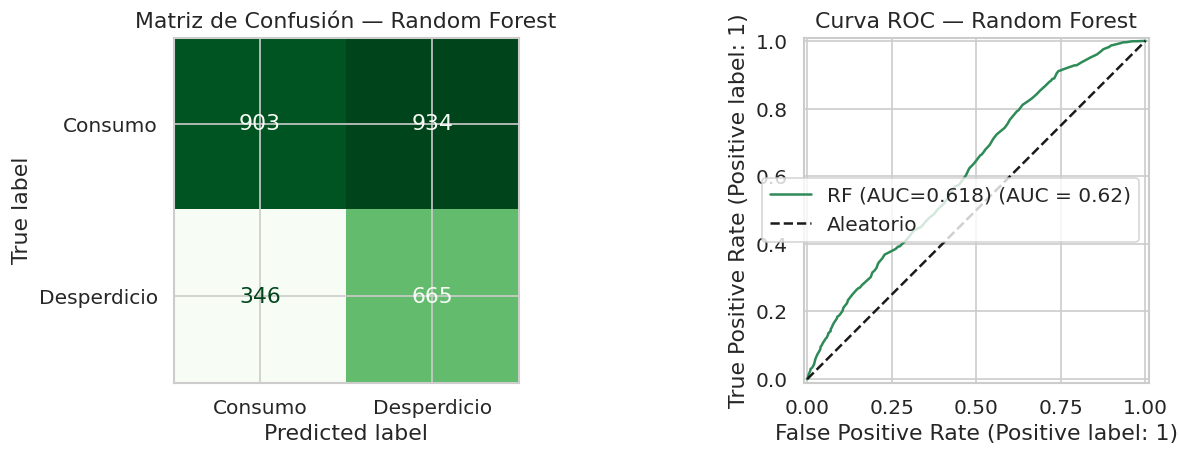

In [19]:
# ─── 7.4 Confusión y ROC ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Consumo','Desperdicio'],
    colorbar=False, ax=axes[0], cmap='Greens'
)
axes[0].set_title('Matriz de Confusión — Random Forest')
RocCurveDisplay.from_predictions(
    y_test, y_proba_rf, name=f'RF (AUC={auc_rf:.3f})', ax=axes[1], color='seagreen'
)
axes[1].plot([0,1],[0,1],'k--',label='Aleatorio')
axes[1].set_title('Curva ROC — Random Forest'); axes[1].legend()
plt.tight_layout()
plt.savefig('../outputs/rf_confusion_roc.png', bbox_inches='tight')
plt.show()

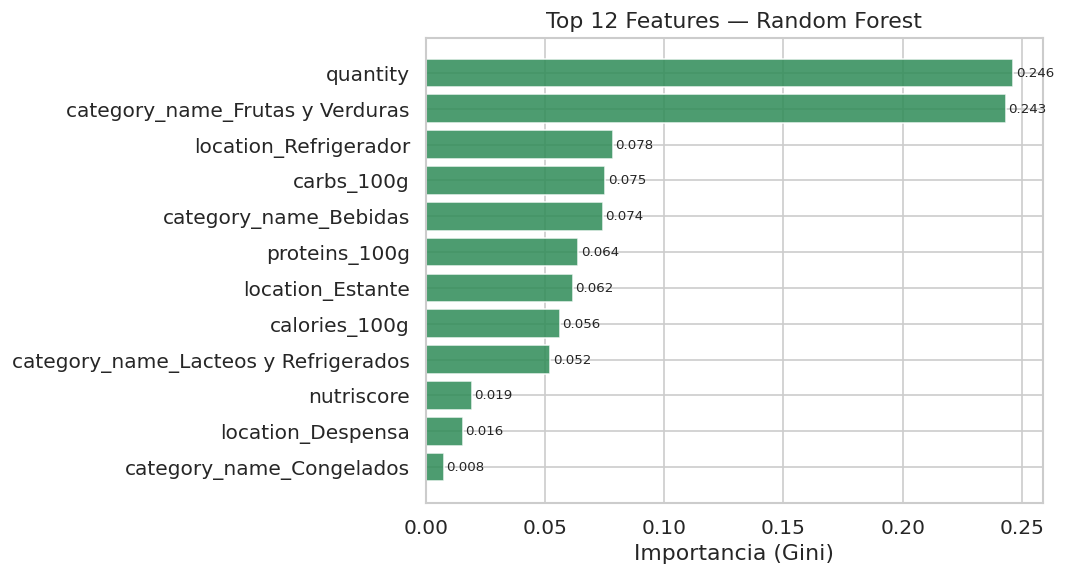

Top 5 features más predictivas:
                        feature  importance
                       quantity    0.246468
category_name_Frutas y Verduras    0.243250
          location_Refrigerador    0.078434
                     carbs_100g    0.075359
          category_name_Bebidas    0.074385


In [20]:
# ─── 7.5 Importancia de features ──────────────────────────────────────────────
ohe_feats = (
    pipeline_rf.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['onehot']
    .get_feature_names_out(CATEGORICAL_FEATURES)
)
all_names   = NUMERIC_FEATURES + list(ohe_feats) + ORDINAL_FEATURES
importances = pipeline_rf.named_steps['classifier'].feature_importances_
feat_imp    = pd.DataFrame({'feature': all_names, 'importance': importances})\
               .sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(feat_imp['feature'], feat_imp['importance'], color='seagreen', alpha=0.85)
ax.set_xlabel('Importancia (Gini)'); ax.set_title('Top 12 Features — Random Forest')
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../outputs/rf_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features más predictivas:')
print(feat_imp[['feature','importance']].head(5).to_string(index=False))

---
## 8. Comparación de métricas

### Justificación de métricas

| Métrica | Justificación |
|---|---|
| **F1-Score** *(primaria)* | Balancea Precision y Recall sin privilegiar la clase mayoritaria (64.5% Consumo). |
| **ROC-AUC** | Mide capacidad discriminante independientemente del umbral de decisión. |
| **Recall** | Detectar pérdidas reales es prioritario; un falso negativo tiene mayor costo que un falso positivo. |
| **Precision** | Limita alertas falsas que confundirían al usuario. |
| **Accuracy** | Reportada por completitud — **no es la métrica de selección** por el desbalance de clases. |

In [21]:
# ─── 8.1 Tabla comparativa numérica ───────────────────────────────────────────
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística (baseline)', 'Random Forest (principal)'],
    'Accuracy':  [round(acc_lr, 4),  round(acc_rf, 4)],
    'Precision': [round(prec_lr, 4), round(prec_rf, 4)],
    'Recall':    [round(rec_lr, 4),  round(rec_rf, 4)],
    'F1-Score':  [round(f1_lr, 4),   round(f1_rf, 4)],
    'ROC-AUC':   [round(auc_lr, 4),  round(auc_rf, 4)],
    'F1 CV (media ± std)': [
        f'{cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}',
        f'{cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}'
    ]
}).set_index('Modelo')

print('═══════════════════════════════════════════════════════════════')
print('          COMPARACIÓN DE MÉTRICAS — AMBOS MODELOS             ')
print('═══════════════════════════════════════════════════════════════')
print(resultados.to_string())

═══════════════════════════════════════════════════════════════
          COMPARACIÓN DE MÉTRICAS — AMBOS MODELOS             
═══════════════════════════════════════════════════════════════
                                Accuracy  Precision  Recall  F1-Score  ROC-AUC F1 CV (media ± std)
Modelo                                                                                            
Regresión Logística (baseline)    0.5779     0.4309  0.5895    0.4979   0.6231     0.4904 ± 0.0165
Random Forest (principal)         0.5506     0.4159  0.6578    0.5096   0.6181     0.5027 ± 0.0071


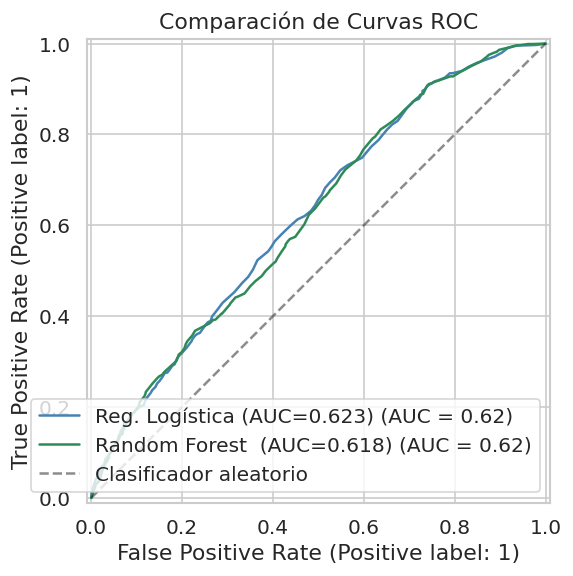

In [22]:
# ─── 8.2 Curvas ROC superpuestas ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_lr,
    name=f'Reg. Logística (AUC={auc_lr:.3f})', ax=ax, color='steelblue')
RocCurveDisplay.from_predictions(y_test, y_proba_rf,
    name=f'Random Forest  (AUC={auc_rf:.3f})', ax=ax, color='seagreen')
ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Clasificador aleatorio')
ax.set_title('Comparación de Curvas ROC'); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/comparacion_roc.png', bbox_inches='tight')
plt.show()

---
## 9. Conclusión técnica y selección del modelo final

In [23]:
# ─── 9.1 Evidencia cuantitativa ───────────────────────────────────────────────
mejora_f1  = (f1_rf - f1_lr) / f1_lr * 100
mejora_rec = (rec_rf - rec_lr) / rec_lr * 100

print('════════════════════════════════════════════════════════════════')
print('              CONCLUSIÓN TÉCNICA — MODELO SELECCIONADO          ')
print('════════════════════════════════════════════════════════════════')
print(f'  Ganancia en F1-Score vs baseline: {mejora_f1:+.1f}%')
print(f'  Ganancia en Recall   vs baseline: {mejora_rec:+.1f}%')
print()
print('  MODELO SELECCIONADO: Random Forest Classifier')
print()
print('  Fundamentos cuantitativos:')
print(f'  1. F1 superior: {f1_rf:.4f} vs {f1_lr:.4f} (+{mejora_f1:.1f}%).')
print(f'  2. Recall superior: {rec_rf:.4f} vs {rec_lr:.4f} — detecta más pérdidas reales.')
print(f'  3. CV más estable: std={cv_scores_rf.std():.4f} vs {cv_scores_lr.std():.4f}.')
print(f'  4. Feature más importante: `quantity` y `category_name` — coherente con')
print(f'     la lógica de que ciertos productos (Frutas y Verduras) y grandes')
print(f'     cantidades tienen mayor propensión al desperdicio.')
print()
print('  INTERPRETACIÓN DEL RENDIMIENTO MODERADO (F1 ≈ 0.51):')
print('  Sin acceso a dias_para_vencer, los modelos aprenden de características')
print('  del producto (categoría, nutrientes, cantidad). El rendimiento moderado')
print('  es esperado y honesto: refleja que el perfil nutricional solo explica')
print('  parcialmente el desperdicio cuando no se conoce la fecha de vencimiento.')
print()
print('  LIMITACIONES DECLARADAS:')
print('  - Dataset simulado: requiere validación con datos observacionales reales.')
print('  - dias_para_vencer excluida por leakage — en producción podría usarse')
print('    si se calcula ANTES del evento (stock actual, no al momento de la salida).')
print('════════════════════════════════════════════════════════════════')

════════════════════════════════════════════════════════════════
              CONCLUSIÓN TÉCNICA — MODELO SELECCIONADO          
════════════════════════════════════════════════════════════════
  Ganancia en F1-Score vs baseline: +2.3%
  Ganancia en Recall   vs baseline: +11.6%

  MODELO SELECCIONADO: Random Forest Classifier

  Fundamentos cuantitativos:
  1. F1 superior: 0.5096 vs 0.4979 (+2.3%).
  2. Recall superior: 0.6578 vs 0.5895 — detecta más pérdidas reales.
  3. CV más estable: std=0.0071 vs 0.0165.
  4. Feature más importante: `quantity` y `category_name` — coherente con
     la lógica de que ciertos productos (Frutas y Verduras) y grandes
     cantidades tienen mayor propensión al desperdicio.

  INTERPRETACIÓN DEL RENDIMIENTO MODERADO (F1 ≈ 0.51):
  Sin acceso a dias_para_vencer, los modelos aprenden de características
  del producto (categoría, nutrientes, cantidad). El rendimiento moderado
  es esperado y honesto: refleja que el perfil nutricional solo explica
  parcial

In [24]:
# ─── 9.2 Exportar tabla de métricas ───────────────────────────────────────────
# outputs/ ya existe — creado en la celda de configuración (code-01)
resultados.to_csv('../outputs/metricas_modelos.csv')
print('✓ Exportado: outputs/metricas_modelos.csv')
print()
print('══ RESUMEN FINAL DEL PIPELINE ══')
print(f'  Fuente        : data/interim/inventory_v1.csv')
print(f'  Subconjunto   : eventos OUT  ({len(model_df):,} registros)')
print(f'  Features      : {len(feature_cols)} variables  (dias_para_vencer excluida — leakage)')
print(f'  Train / Test  : {len(X_train):,} / {len(X_test):,}  (80/20, stratify=True)')
print(f'  Baseline   LR : F1={f1_lr:.4f} | AUC={auc_lr:.4f} | Recall={rec_lr:.4f}')
print(f'  Principal  RF : F1={f1_rf:.4f} | AUC={auc_rf:.4f} | Recall={rec_rf:.4f}')
print(f'  Decisión      : RF seleccionado (mayor F1, Recall y estabilidad CV)')
print(f'  Reproducible  : seed={RANDOM_STATE}, CV=5-fold')

✓ Exportado: outputs/metricas_modelos.csv

══ RESUMEN FINAL DEL PIPELINE ══
  Fuente        : data/interim/inventory_v1.csv
  Subconjunto   : eventos OUT  (14,238 registros)
  Features      : 7 variables  (dias_para_vencer excluida — leakage)
  Train / Test  : 11,390 / 2,848  (80/20, stratify=True)
  Baseline   LR : F1=0.4979 | AUC=0.6231 | Recall=0.5895
  Principal  RF : F1=0.5096 | AUC=0.6181 | Recall=0.6578
  Decisión      : RF seleccionado (mayor F1, Recall y estabilidad CV)
  Reproducible  : seed=42, CV=5-fold
